In [2]:
!pip install torch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
    --------------------------------------- 2.9/123.0 MB 20.1 MB/s eta 0:00:06
   -- ------------------------------------- 6.3/123.0 MB 18.6 MB/s eta 0:00:07
   --- ------------------------------------ 10.5/123.0 MB 21.7 MB/s eta 0:00:06
   ---- ----------------------------------- 12.6/123.0 MB 16.6 MB/s eta 0:00:07
   ---- ----------------------------------- 13.9/123.0 MB 14.6 MB/s eta 0:00:08
   ---- ----------------------------------- 14.9/123.0 MB 12.6 MB/s eta 0:00:09
   ----- ---------------------------------- 16.0/123.0 MB 11.4 MB/s eta 0:00:10
   ----- ---------------------------------- 17.0/123.0 MB 10.5 MB/s eta 0:00:11
   ----- ---------------------------------- 18.1/123.0 MB 9.9 MB/s eta 0:00:11
   ------ --------------------------------- 19.1/123.0 MB 9.5 MB/s eta 0:00:11
   -----


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
import numpy as np
import joblib

In [53]:
X_train = np.load(
    "../data/processed/X_train.npy"
)

X_test = np.load(
    "../data/processed/X_test.npy"
)

y_train = np.load(
    "../data/processed/y_train.npy"
)

y_test = np.load(
    "../data/processed/y_test.npy"
)

In [54]:
label_encoder = joblib.load(
    "../data/processed/label_encoder.pkl"
)

In [55]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(189, 2151)
(48, 2151)
(189,)
(48,)


In [56]:
import torch

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([189, 2151])
torch.Size([189])


In [57]:
X_train_tensor = X_train_tensor.unsqueeze(1)

X_test_tensor = X_test_tensor.unsqueeze(1)

print(X_train_tensor.shape)
print(X_test_tensor.shape)

torch.Size([189, 1, 2151])
torch.Size([48, 1, 2151])


In [58]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches :", len(test_loader))

Train batches: 12
Test batches : 3


In [59]:
import torch.nn as nn

class MineralCNN(nn.Module):

    def __init__(self, num_classes=38):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                16,
                32,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                32 * 537,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [60]:
model = MineralCNN(
    num_classes=38
)

print(model)

MineralCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=17184, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=38, bias=True)
  )
)


In [61]:
sample_batch = next(
    iter(train_loader)
)

X_batch, y_batch = sample_batch

outputs = model(X_batch)

print(outputs.shape)

torch.Size([16, 38])


In [62]:
print(X_train_tensor.shape)
print(X_test_tensor.shape)

print(len(train_loader))
print(len(test_loader))

print(outputs.shape)

torch.Size([189, 1, 2151])
torch.Size([48, 1, 2151])
12
3
torch.Size([16, 38])


In [63]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Ready")

Ready


In [64]:
num_epochs = 30

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/30] Loss: 3.7697
Epoch [2/30] Loss: 3.2444
Epoch [3/30] Loss: 2.9680
Epoch [4/30] Loss: 2.7054
Epoch [5/30] Loss: 2.4245
Epoch [6/30] Loss: 2.1648
Epoch [7/30] Loss: 1.9992
Epoch [8/30] Loss: 1.8302
Epoch [9/30] Loss: 1.7280
Epoch [10/30] Loss: 1.6301
Epoch [11/30] Loss: 1.4127
Epoch [12/30] Loss: 1.4373
Epoch [13/30] Loss: 1.3177
Epoch [14/30] Loss: 1.1625
Epoch [15/30] Loss: 1.1336
Epoch [16/30] Loss: 0.9947
Epoch [17/30] Loss: 1.0771
Epoch [18/30] Loss: 1.0144
Epoch [19/30] Loss: 0.9474
Epoch [20/30] Loss: 0.9697
Epoch [21/30] Loss: 0.8144
Epoch [22/30] Loss: 0.7979
Epoch [23/30] Loss: 0.7054
Epoch [24/30] Loss: 0.7574
Epoch [25/30] Loss: 0.8122
Epoch [26/30] Loss: 0.6929
Epoch [27/30] Loss: 0.6309
Epoch [28/30] Loss: 0.7232
Epoch [29/30] Loss: 0.6894
Epoch [30/30] Loss: 0.6117


In [65]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += y_batch.size(0)

        correct += (
            predicted == y_batch
        ).sum().item()

accuracy = 100 * correct / total

print(
    f"Test Accuracy: {accuracy:.2f}%"
)

Test Accuracy: 47.92%


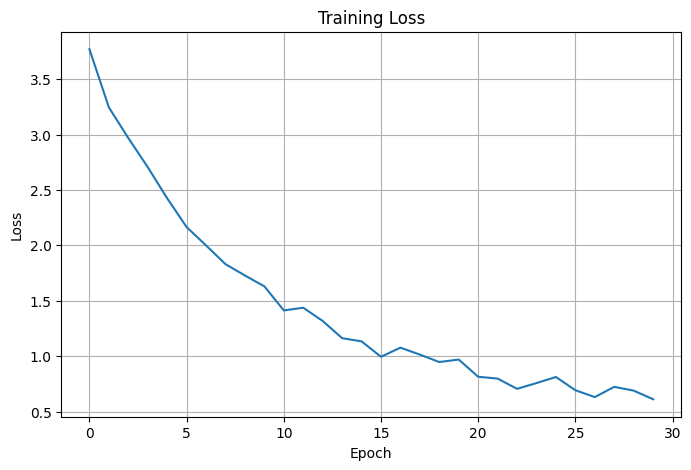

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

In [67]:
torch.save(
    model.state_dict(),
    "../models/cnn/mineral_cnn_v1.pth"
)

In [19]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.numpy())
        all_labels.extend(y_batch.numpy())

cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm.shape)

(38, 38)


c:\Users\prewa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\prewa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\Users\prewa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
c:\Users\prewa\AppData\Loca

In [21]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for X_batch, y_batch in train_loader:

        outputs = model(X_batch)

        _, predicted = torch.max(outputs, 1)

        total += y_batch.size(0)

        correct += (predicted == y_batch).sum().item()

train_acc = 100 * correct / total

print("Train Accuracy:", train_acc)

Train Accuracy: 83.06878306878306


In [68]:
print(model)

MineralCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=17184, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=38, bias=True)
  )
)


In [69]:
model = MineralCNN()

model.load_state_dict(
    torch.load("../models/cnn/mineral_cnn_v1.pth")
)

model.eval()

print("Loaded: mineral_cnn_v1.pth")

Loaded: mineral_cnn_v1.pth


# =====================================
# FINAL BASELINE RESULTS
# =====================================

Dataset:
237 spectra
38 minerals
2151 spectral bands

Model:
1D CNN

Train Accuracy:
83.07%

Test Accuracy:
41.67%